/tmp/ipykernel_3114184/3246375502.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


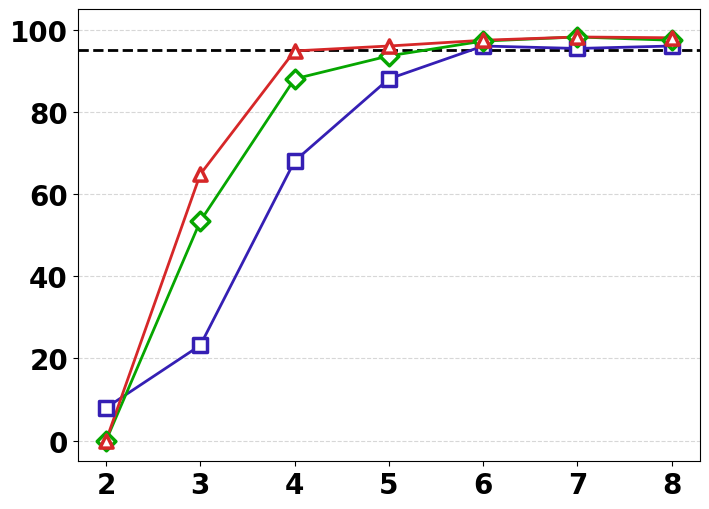

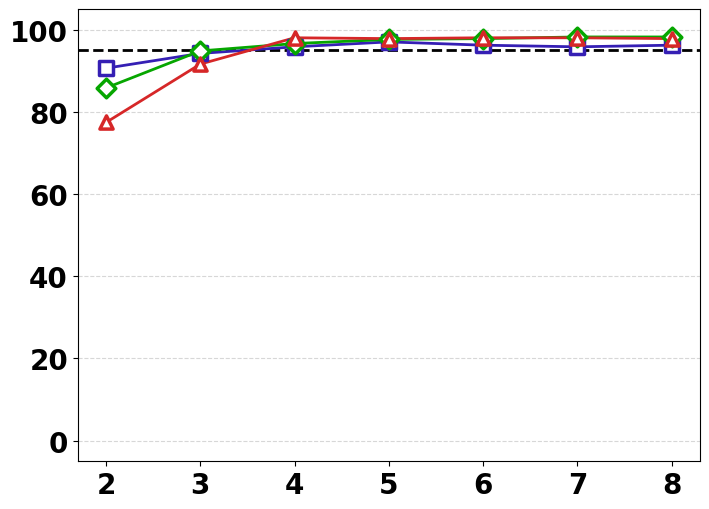

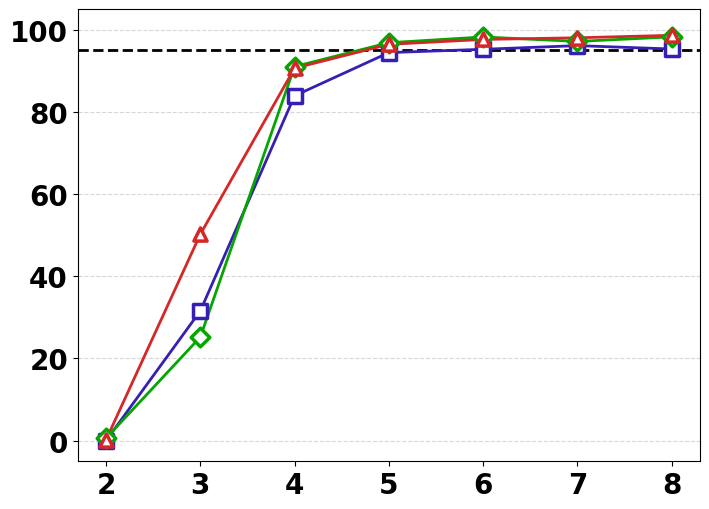

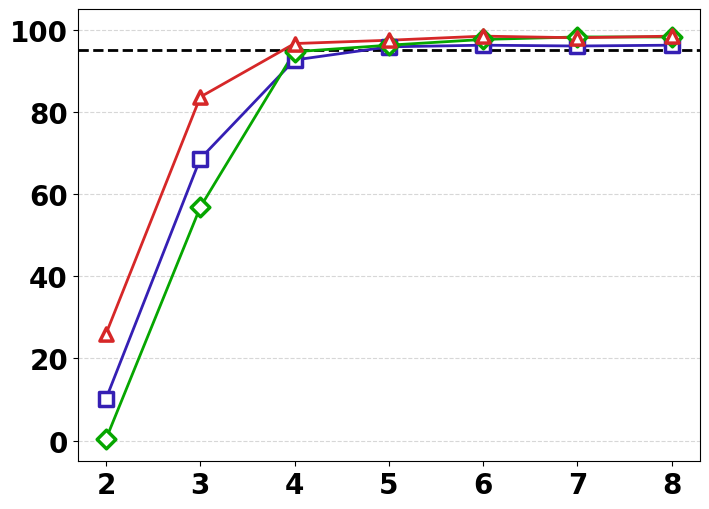

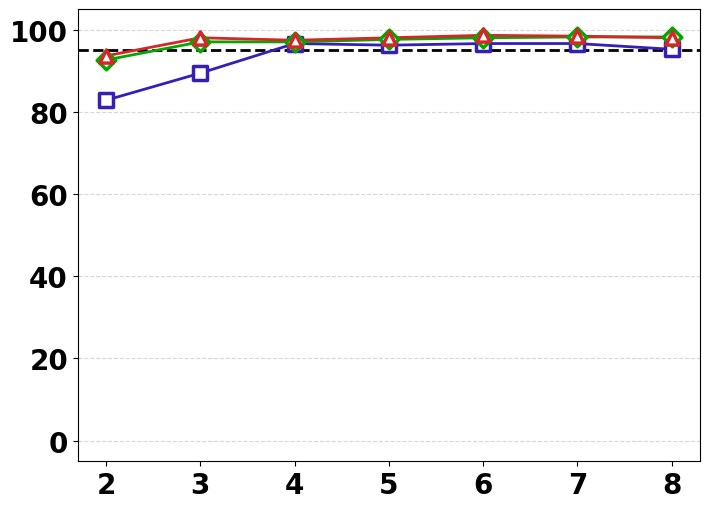

In [2]:
import pandas as pd
import glob
import re
import matplotlib.pyplot as plt
import numpy as np

# --- パターン定義（この順で図が出る） ---
patterns = [
    "/work/robomimic/csv/eval/lift/quantize/weight/unit*.csv",
    "/work/robomimic/csv/eval/lift/quantize/LUT/unit*.csv",
    "/work/robomimic/csv/eval/lift/quantize/CAM/calibration/u*.csv",
    "/work/robomimic/csv/eval/lift/quantize/digital/calibration/u*.csv",
    "/work/robomimic/csv/eval/lift/quantize/digital/fixed/u*.csv",
]

def extract_bit(filename: str):
    m = re.search(r"quantized_(\d+)bit", filename)
    return int(m.group(1)) if m else None

def extract_base_model(name: str):
    # seed 除去
    name = re.sub(r"_seed\d+", "", name)

    # quantized_xbit 以降を除去
    name = re.sub(r"_?quantized[_\-]?\d+\s*bit.*", "", name)

    # unit64 → u64 正規化
    name = name.replace("unit64", "u64")
    name = name.replace("unit128", "u128")
    name = name.replace("unit256", "u256")

    return name

# --- 描画設定 ---
custom_colors = {
    "ncp_u64_best":  "#351fb4",
    "u64":      "#351fb4",
    "ncp_u128_best": "#06a600",
    "u128":     "#06a600",
    "ncp_u256_best": "#d62728",
    "u256":     "#d62728",
}

markers = {
    "ncp_u64_best":  "s",
    "u64":      "s",
    "ncp_u128_best": "D",
    "u128":     "D",
    "ncp_u256_best": "^",
    "u256":     "^",
}

plot_order = ["ncp_u64_best","u64", "ncp_u128_best", "u128", "ncp_u256_best", "u256"]

# ===============================
# pattern ごとに「順番に」描画
# ===============================
for pattern in patterns:

    csv_files = sorted(glob.glob(pattern))
    if len(csv_files) == 0:
        continue

    df_list = []
    for file in csv_files:
        bit = extract_bit(file)
        if bit is None:
            continue
        df = pd.read_csv(file)
        df["bit"] = bit
        df["base_model"] = df["name"].apply(extract_base_model)
        df_list.append(df)

    if len(df_list) == 0:
        continue

    df_all = pd.concat(df_list, ignore_index=True)

    # --- 集計 ---
    df_agg = (
        df_all.groupby(["base_model", "bit"])["success_rate"]
              .mean()
              .reset_index()
    )
    df_agg = df_agg[df_agg["bit"] != 1]

    # ===== 描画 =====
    plt.figure(figsize=(7.2, 5.2))

    # 95% 基準線（背面）
    plt.axhline(
        95,
        color="black",
        linestyle="--",
        linewidth=2.0,
        zorder=-10,
    )

    for base_model in plot_order:
        df_m = df_agg[df_agg["base_model"] == base_model].sort_values("bit")
        if df_m.empty:
            continue

        bits  = df_m["bit"].values
        means = df_m["success_rate"].values * 100

        color  = custom_colors[base_model]
        marker = markers[base_model]

        plt.plot(bits, means, color=color, linewidth=2.0, zorder=5)
        plt.scatter(
            bits, means,
            marker=marker,
            s=90,
            facecolors="white",
            edgecolors=color,
            linewidths=2.5,
            zorder=6,
        )

    plt.ylim(-5, 105)
    plt.xticks(sorted(df_agg["bit"].unique()))

    plt.tick_params(axis="both", labelsize=20)
    for lbl in plt.gca().get_xticklabels() + plt.gca().get_yticklabels():
        lbl.set_fontweight("bold")

    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_lnn_memory_impact(
    neuron_counts=[64],    # ニューロン数
    input_dim=16,                     # 外部入力次元数
    
    # --- 1. Baseline: FP32 (Software / GPU Standard) ---
    fp32_bits=32,                     # 重みも状態もすべて32bit
    
    # --- 2. Competitor: INT8 (Standard Edge NPU) ---
    int8_bits=8,                      # 一般的な量子化モデル
    
    # --- 3. Proposed: LNN Accelerator (Ours) ---
    # CAM/LUTの設定
    prop_cam_in_bits=4,               # 提案: 入力は4bitに大胆に量子化（リストも可）
    prop_lut_out_bits=4,              # 提案: LUTの値は8bit（リストも可）
    prop_processor_sram_bits=8,            # 提案: その他プロセッサオーバーヘッドは8bit（リストも可）
    prop_processor_rram_bits=8,            # 提案: その他プロセッサオーバーヘッドは8bit（リストも可）
    # MVM(重み)の設定
    prop_weight_bits=4                # 提案: 重みは4bit（リストも可）
):
    """
    FP32, INT8, 提案手法の3つのメモリ容量を比較するシミュレーション
    各量子化パラメータはリストでも単一値でも可
    """
    
    results = []
    
    # 各パラメータがリストかどうか判定し、リスト化
    def ensure_list(x):
        return x if isinstance(x, (list, tuple, np.ndarray)) else [x]

    cam_bits_list = ensure_list(prop_cam_in_bits)
    lut_bits_list = ensure_list(prop_lut_out_bits)
    proc_sram_bits_list = ensure_list(prop_processor_sram_bits)
    proc_rram_bits_list = ensure_list(prop_processor_rram_bits)
    weight_bits_list = ensure_list(prop_weight_bits)

    for n_neuron in neuron_counts:
        for cam_bits in cam_bits_list:
            for lut_bits in lut_bits_list:
                for proc_sram_bits in proc_sram_bits_list:
                    for proc_rram_bits in proc_rram_bits_list:
                        for weight_bits in weight_bits_list:
                            # 共通パラメータ: 重みの総数
                            total_params_weight = (n_neuron + input_dim) * n_neuron
                            
                            # 1. Baseline: FP32 (Full Precision)
                            size_fp32_mvm = total_params_weight * fp32_bits
                            total_fp32_kbits = size_fp32_mvm / 1000
                            
                            # 2. Competitor: INT8 (Standard Quantization)
                            size_int8_mvm = total_params_weight * int8_bits * 2
                            size_int8_cam = (2**int8_bits) * int8_bits # CAM overhead
                            size_int8_lut = n_neuron * (2**int8_bits) * int8_bits # LUT overhead
                            size_int8_processor = 4 * n_neuron * int8_bits # その他プロセッサオーバーヘッド
                            total_int8_kbits = (size_int8_mvm + size_int8_cam + size_int8_lut + size_int8_processor) / 1000
                            
                            # 3. Proposed (Mixed Precision & Architecture)
                            size_prop_mvm = total_params_weight * weight_bits * 2
                            entries = 2 ** cam_bits
                            size_prop_cam = entries * cam_bits # Key
                            size_prop_lut = n_neuron * entries * lut_bits # Value
                            size_prop_processor = n_neuron * (3 * proc_rram_bits + proc_sram_bits) # その他プロセッサオーバーヘッド
                            total_prop_kbits = (size_prop_mvm + size_prop_cam + size_prop_lut + size_prop_processor) / 1000
                            
                            # 削減率の計算 (vs FP32)
                            reduction_vs_fp32 = (total_prop_kbits / total_fp32_kbits) * 100
                            reduction_vs_int8 = (total_prop_kbits / total_int8_kbits) * 100
                            
                            results.append({
                                "Neuron Count": n_neuron,
                                "CAM Size": size_prop_cam,
                                "LUT Size": size_prop_lut,
                                "Processor Size": size_prop_processor,
                                "MVM Size": size_prop_mvm,
                                "FP32 Size (kbits)": total_fp32_kbits,
                                "INT8 Size (kbits)": total_int8_kbits,
                                "Ours Size (kbits)": total_prop_kbits,
                                "Red. vs FP32 (%)": reduction_vs_fp32,
                                "Red. vs INT8 (%)": reduction_vs_int8
                            })
        return pd.DataFrame(results)

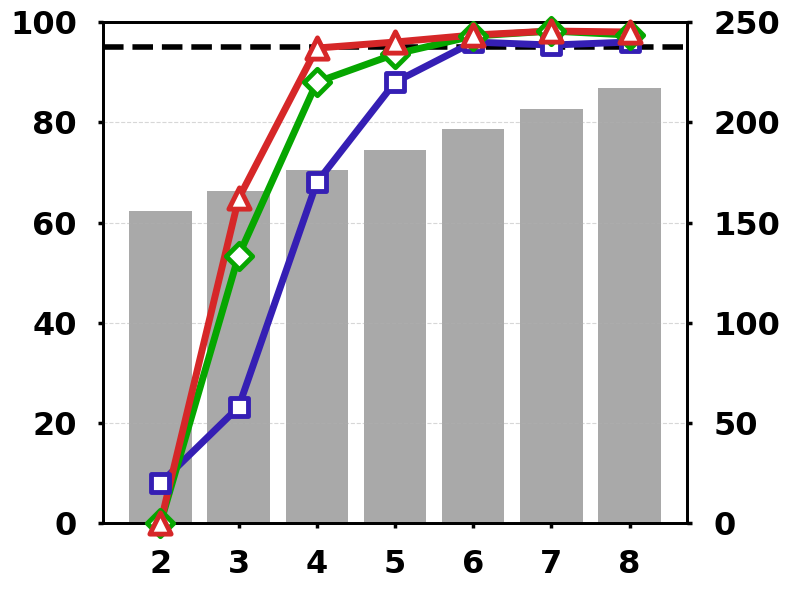

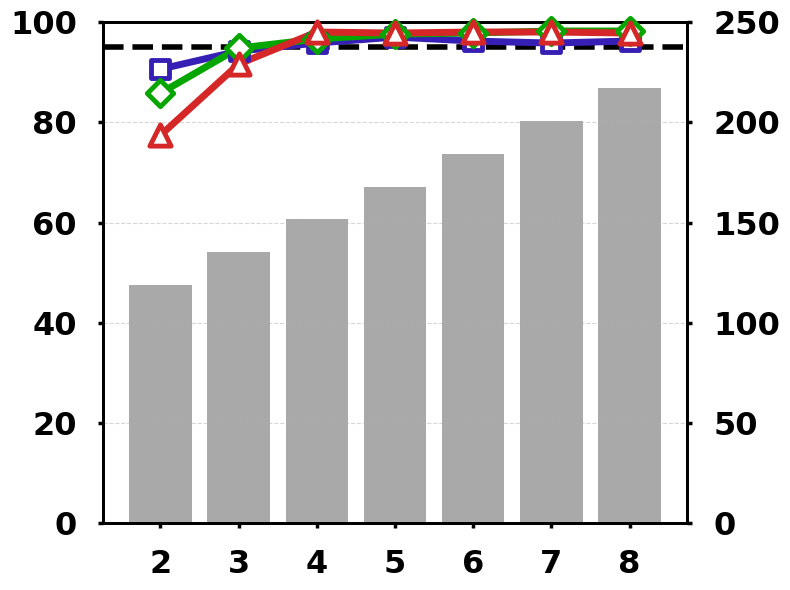

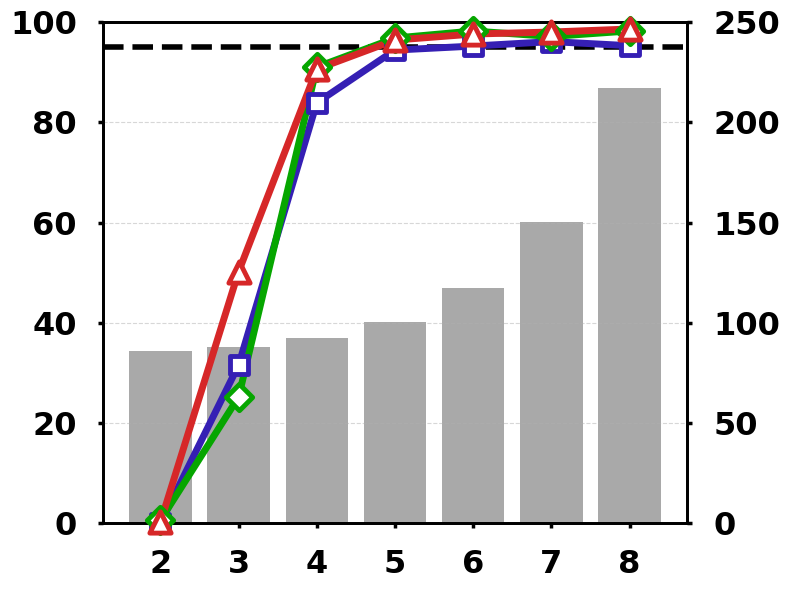

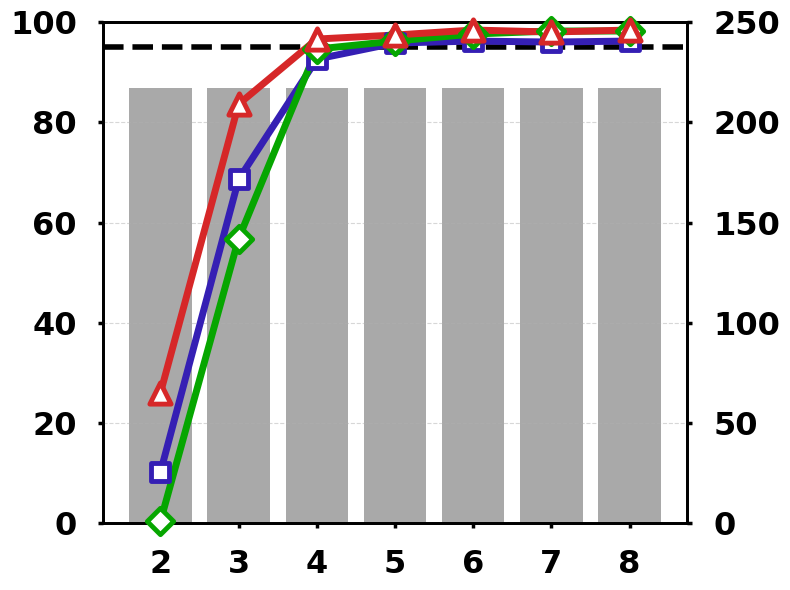

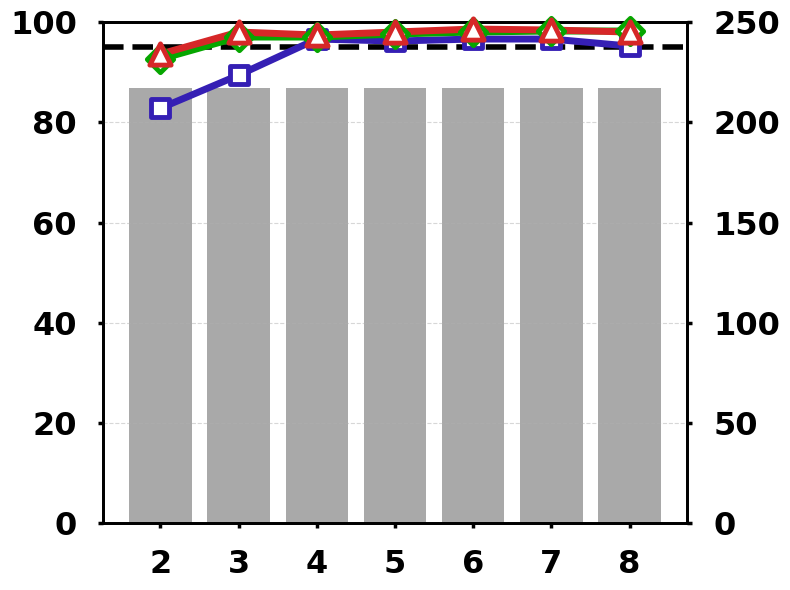

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. メモリ計算処理 (変更なし) ---
def get_total_memory_for_block_variation(target_block, target_bits=[2, 3, 4, 5, 6, 7, 8]):
    total_memory_series = {}
    for b in target_bits:
        params = {
            "prop_cam_in_bits": 8, "prop_lut_out_bits": 8, "prop_weight_bits": 8,
            "prop_processor_sram_bits": 8, "prop_processor_rram_bits": 8
        }
        if target_block == "CAM": params["prop_cam_in_bits"] = b
        elif target_block == "LUT": params["prop_lut_out_bits"] = b
        elif target_block == "MVM": params["prop_weight_bits"] = b

        df_res = analyze_lnn_memory_impact(neuron_counts=[64], **params)
        total_memory_series[b] = df_res.iloc[0]["Ours Size (kbits)"]
    return total_memory_series

# --- 2. 描画処理 ---
for pattern in patterns:
    csv_files = sorted(glob.glob(pattern))
    if not csv_files: continue

    # データ集計
    df_list = []
    for file in csv_files:
        bit = extract_bit(file)
        if bit is None: continue
        df = pd.read_csv(file)
        df["bit"], df["base_model"] = bit, df["name"].apply(extract_base_model)
        df_list.append(df)
    df_all = pd.concat(df_list, ignore_index=True)
    df_agg = df_all.groupby(["base_model", "bit"])["success_rate"].mean().reset_index()
    df_agg = df_agg[df_agg["bit"] != 1]

    target_block = "MVM"
    if "CAM" in pattern: target_block = "CAM"
    elif "LUT" in pattern: target_block = "LUT"
    elif "digital" in pattern: target_block = "SRAM-Buffer"
    
    bits_range = sorted(df_agg["bit"].unique())
    total_mem_map = get_total_memory_for_block_variation(target_block, bits_range)

    # Figureの生成: ax2 (棒) を先に作り、ax1 (折れ線) をその上に作る
    fig, ax2 = plt.subplots(figsize=(8, 6))
    ax1 = ax2.twinx() # 軸を入れ替えて制御しやすくします
    
    # --- 軸の役割を再定義 ---
    # ax2: 左側(成功率), ax1: 右側(メモリ) となるように調整
    # ただし今回は ax1 を最前面(折れ線)にするため、以下の順序で描画します
    
    # 棒グラフ用の軸 (後ろ側)
    ax_bar = ax2
    # 折れ線グラフ用の軸 (前側)
    ax_line = ax1

    # --- 1. グリッドと目盛りの同期 (50刻み) ---
    total_vals = [total_mem_map[b] for b in bits_range]
    mem_max = max(total_vals) if total_vals else 200
    # 右軸を50刻みでキリ良く設定 (例: 250, 300...)
    ax1_upper = np.ceil((mem_max * 1.1) / 50) * 50
    if ax1_upper < 150: ax1_upper = 150 # 最低限の高さ
    
    ax_line.set_ylim(0, ax1_upper)
    ax_bar.set_ylim(0, 100) # 左軸は0-100

    # 目盛り位置を計算 (50刻みなら、0, 50, 100, 150... となるように分割)
    n_ticks = int(ax1_upper / 50) + 1
    ax_line.set_yticks(np.linspace(0, ax1_upper, n_ticks))
    ax_bar.set_yticks(np.linspace(0, 100, n_ticks))

    # グリッドは ax_bar (左軸) に紐付けて描画
    ax_bar.grid(True, axis='y', linestyle='--', alpha=0.5, zorder=0)

    # --- 2. 棒グラフ (中間) ---
    ax_line.bar(bits_range, total_vals, color="#555555", alpha=0.5, zorder=1)
    
    # --- 3. 折れ線グラフ (最前面) ---
    ax_bar.axhline(95, color="black", linestyle="--", linewidth=4, zorder=2)
    
    for base_model in plot_order:
        df_m = df_agg[df_agg["base_model"] == base_model].sort_values("bit")
        if df_m.empty: continue

        marker = markers[base_model]
        base_size = 180
        marker_size = int(base_size * 1.3) if marker in ["^", "v", "<", ">"] else base_size

        # clip_on=False で枠線を貫通させる
        ax_bar.plot(df_m["bit"], df_m["success_rate"] * 100, 
                    color=custom_colors[base_model], linewidth=5, zorder=10, clip_on=False)
        ax_bar.scatter(df_m["bit"], df_m["success_rate"] * 100, 
                       marker=marker, s=marker_size, facecolors="white", 
                       edgecolors=custom_colors[base_model], linewidths=3.5, 
                       zorder=11, clip_on=False)

    # --- 仕上げ ---
    ax_bar.set_xlabel(""); ax_bar.set_ylabel(""); ax_line.set_ylabel("")
    plt.title("")

    # 軸の数字設定
    for ax in [ax_bar, ax_line]:
        # labelsizeは23を維持し、pad（数字と軸の距離）を15程度に設定
        ax.tick_params(axis="both", labelsize=23, width=2.5, pad=15)
        
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight("bold")
        for spine in ax.spines.values():
            spine.set_linewidth(2)

    ax_bar.set_xticks(bits_range)
    
    # 重なり順の強制 (折れ線の ax_bar を上に)
    ax_bar.set_zorder(ax_line.get_zorder() + 1)
    ax_bar.patch.set_visible(False) 
    
    plt.tight_layout()
    plt.show()

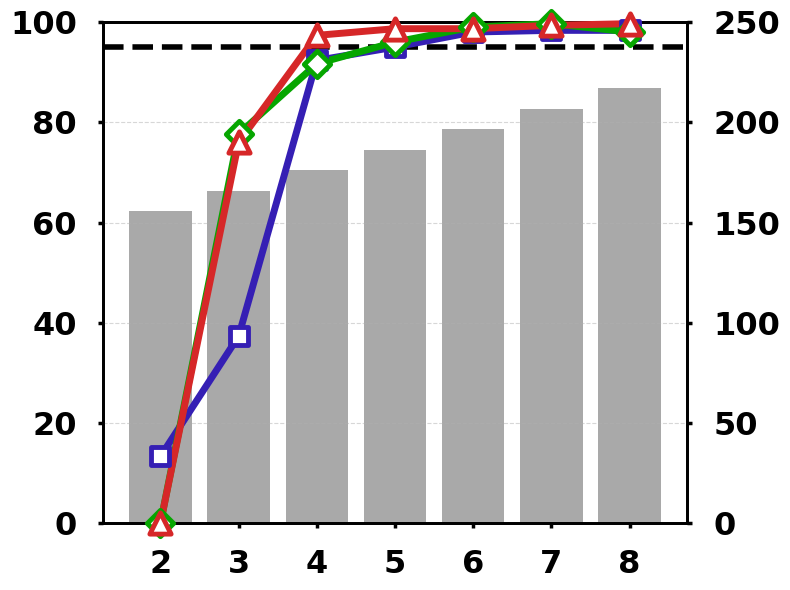

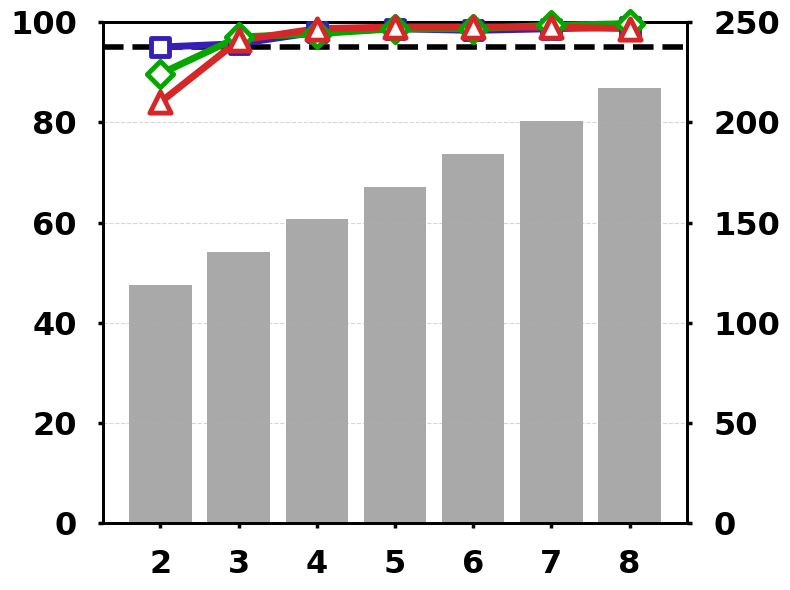

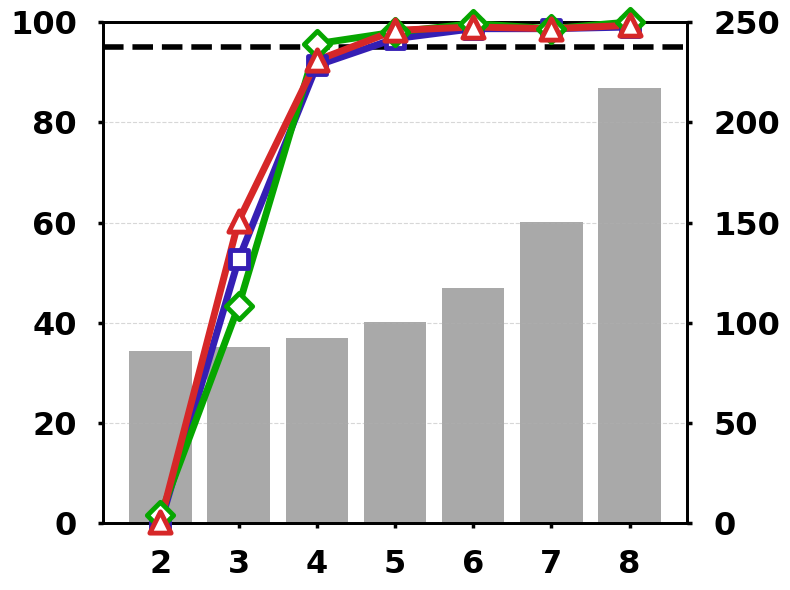

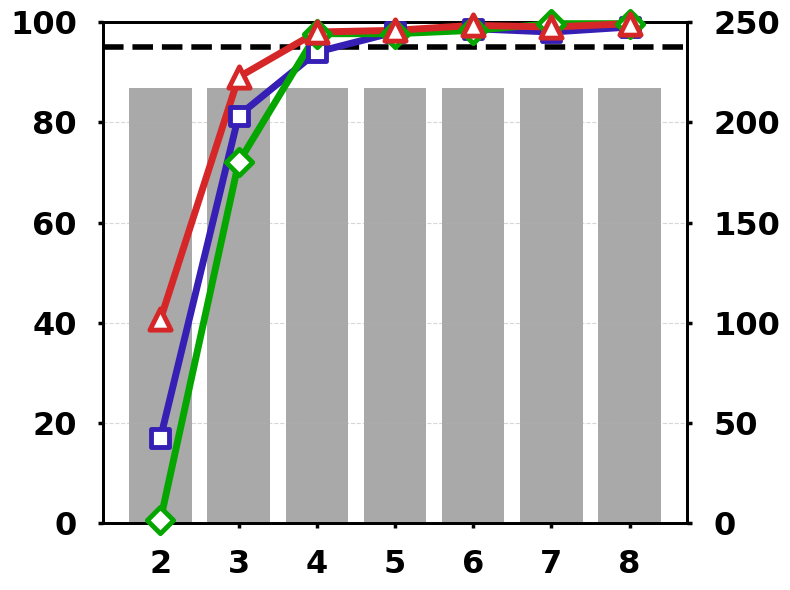

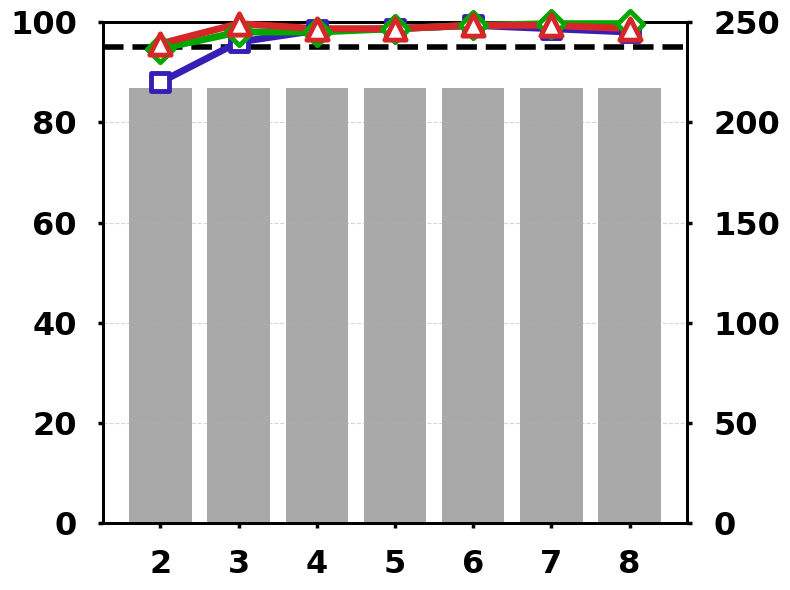

In [5]:
# --- 各bitごとにseed上位3つの平均を出す関数 ---
def get_top3_mean_by_bit(df, group_cols=["base_model", "bit"], value_col="success_rate"):
    # group_colsでグループ化し、各グループごとに上位3つの平均を計算
    def top3_mean(x):
        return x.nlargest(3).mean()
    return (
        df.groupby(group_cols)[value_col]
          .apply(top3_mean)
          .reset_index(name=f"top3_mean_{value_col}")
    )

# --- 2. 描画処理（上位3seed平均で描画） ---
for pattern in patterns:
    csv_files = sorted(glob.glob(pattern))
    if not csv_files: continue

    # データ集計
    df_list = []
    for file in csv_files:
        bit = extract_bit(file)
        if bit is None: continue
        df = pd.read_csv(file)
        df["bit"], df["base_model"] = bit, df["name"].apply(extract_base_model)
        df_list.append(df)
    df_all = pd.concat(df_list, ignore_index=True)
    df_agg = get_top3_mean_by_bit(df_all, ["base_model", "bit"], "success_rate")
    df_agg = df_agg[df_agg["bit"] != 1]

    target_block = "MVM"
    if "CAM" in pattern: target_block = "CAM"
    elif "LUT" in pattern: target_block = "LUT"
    elif "digital" in pattern: target_block = "SRAM-Buffer"
    
    bits_range = sorted(df_agg["bit"].unique())
    total_mem_map = get_total_memory_for_block_variation(target_block, bits_range)

    # Figureの生成: ax2 (棒) を先に作り、ax1 (折れ線) をその上に作る
    fig, ax2 = plt.subplots(figsize=(8, 6))
    ax1 = ax2.twinx() # 軸を入れ替えて制御しやすくします
    
    # --- 軸の役割を再定義 ---
    ax_bar = ax2
    ax_line = ax1

    total_vals = [total_mem_map[b] for b in bits_range]
    mem_max = max(total_vals) if total_vals else 200
    ax1_upper = np.ceil((mem_max * 1.1) / 50) * 50
    if ax1_upper < 150: ax1_upper = 150
    ax_line.set_ylim(0, ax1_upper)
    ax_bar.set_ylim(0, 100)
    n_ticks = int(ax1_upper / 50) + 1
    ax_line.set_yticks(np.linspace(0, ax1_upper, n_ticks))
    ax_bar.set_yticks(np.linspace(0, 100, n_ticks))
    ax_bar.grid(True, axis='y', linestyle='--', alpha=0.5, zorder=0)

    ax_line.bar(bits_range, total_vals, color="#555555", alpha=0.5, zorder=1)
    ax_bar.axhline(95, color="black", linestyle="--", linewidth=4, zorder=2)

    for base_model in plot_order:
        df_m = df_agg[df_agg["base_model"] == base_model].sort_values("bit")
        if df_m.empty: continue
        marker = markers[base_model]
        base_size = 180
        marker_size = int(base_size * 1.3) if marker in ["^", "v", "<", ">"] else base_size
        ax_bar.plot(df_m["bit"], df_m["top3_mean_success_rate"] * 100, 
                    color=custom_colors[base_model], linewidth=5, zorder=10, clip_on=False)
        ax_bar.scatter(df_m["bit"], df_m["top3_mean_success_rate"] * 100, 
                       marker=marker, s=marker_size, facecolors="white", 
                       edgecolors=custom_colors[base_model], linewidths=3.5, 
                       zorder=11, clip_on=False)

    ax_bar.set_xlabel(""); ax_bar.set_ylabel(""); ax_line.set_ylabel("")
    plt.title("")
    for ax in [ax_bar, ax_line]:
        ax.tick_params(axis="both", labelsize=23, width=2.5, pad=15)
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight("bold")
        for spine in ax.spines.values():
            spine.set_linewidth(2)
    ax_bar.set_xticks(bits_range)
    ax_bar.set_zorder(ax_line.get_zorder() + 1)
    ax_bar.patch.set_visible(False)
    plt.tight_layout()
    plt.show()
